# Кластеризация в Python

В этом ноутбуке мы подробнее разберёмся, как можно использовать алгоритм DBSCAN на языке Python для работы с реальными данными.

## Как генерировать и визуализировать примеры

В этом ноутбуке мы будем пользоваться классической для работы с массивами данных библиотекой [numpy](https://numpy.org/). Рекомендуем разобраться в её основах.

Главным инструментом для работы с графиками является библиотека matplotlib. Давайте посмотрим, как с её помощью строить те самые графики с точками:

In [1]:
import matplotlib.pyplot as plt
import numpy as np

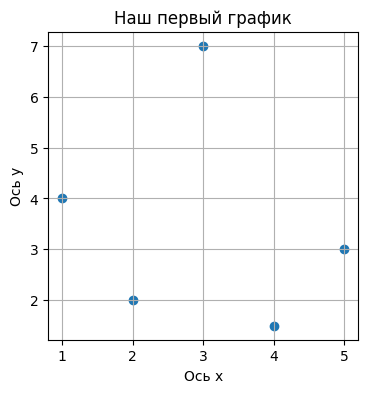

In [2]:
x = [1, 2, 3, 4, 5] # координаты точек по оси x
y = [4, 2, 7, 1.5, 3] # координаты точек по оси y

plt.figure(figsize=(4, 4)) # задаём размер изображения
plt.scatter(x, y) # создаём график из точек с координатами (x[i], y[i])
plt.title('Наш первый график') # добавляем заголовок
plt.xlabel('Ось x') # подпись к первой оси (пригодиться для единиц измерения и т.п.)
plt.ylabel('Ось y') # подпись ко второй оси
plt.grid() # добавляем на график координатную сетку
plt.show() # показываем график

Как видите, matplotlib сам подбирает подходящие шкалы на осях, но если посмотреть [документацию](https://matplotlib.org/stable/gallery/index), их тоже можно легко настроить самому. Оставновимся подробней на аргументах scatter:

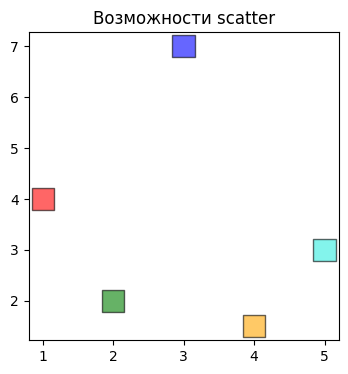

In [3]:
plt.figure(figsize=(4, 4))
plt.scatter(
    x=[1, 2, 3, 4, 5],
    y=[4, 2, 7, 1.5, 3],
    c=['red', 'green', 'blue', 'orange', '#30EEE0'], # цвета точек (можно и RGB-код)
    s=256, # размер точек
    marker='s', # форма точек
    alpha=0.6, # прозрачность точек
    edgecolors='black' # контуры границ точек
)
plt.title('Возможности scatter')
plt.show()

c, s, marker и edgecolors могут быть как списками значений (своё для каждой точки), так и одним значением (тогда оно будет для всех точек). При этом в параметр c можно передать и просто список целых чисел - номеров групп (например, кластеров), на которые разбиваются точки. Тогда каждая группа будет покрашена в общий цвет, а в какой именно - решает параметр cmap (у нас он равен 'viridis', но можно выбрать и [другой](https://matplotlib.org/stable/users/explain/colors/colormaps.html)).

Параметр alpha нужен для контроля прозрачности точек. Значения у него дробные. При alpha=0 точки полностью прозрачны, а при alpha=1 полностью непрозрачны. Мы будем делать alpha=0.8, чтобы было видно, когда в особо плотных скоплениях точки накладываются друг на друга.

Теперь посмотрим, как генерировать данные для тестирования кластеризации. Мы будем использовать классическую библиотеку машинного обученя [sklearn](https://scikit-learn.org/stable/). В ней в том числе есть функции для генерации разных интересных наборов данных. Рассмотрим часть из них:

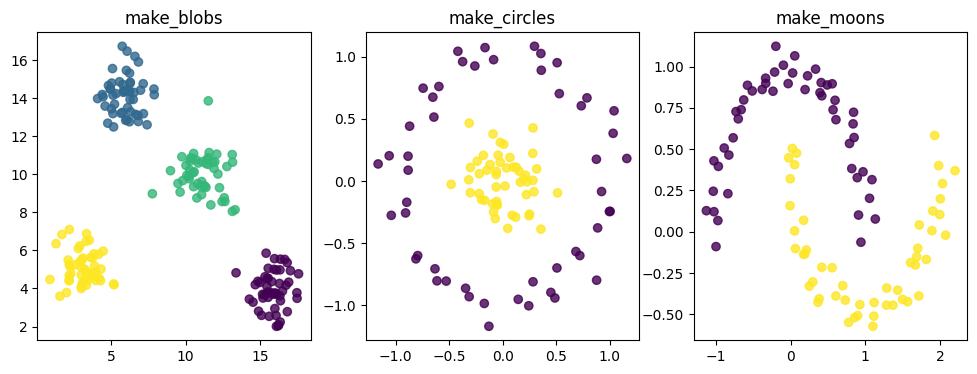

In [4]:
from sklearn.datasets import make_blobs, make_moons, make_circles

datasets = [
    make_blobs(
      n_samples=200,
      centers=[(16, 4), (6, 14), (11, 10), (3, 5)],
      random_state=42
    ),
    make_circles(noise=0.1, factor=0.25, random_state=42),
    make_moons(noise=0.075, random_state=42)
]
names = ['make_blobs', 'make_circles', 'make_moons']

plt.figure(figsize=(12, 4))
for i, (x, y) in enumerate(datasets):
    plt.subplot(1, 3, i + 1)
    plt.title(names[i])
    plt.scatter(x[:, 0], x[:, 1], c=y, cmap='viridis', alpha=0.8)

1) make_blobs просто создаёт случайные скопления точек вокруг заданных центров. Через cluster_std можно задать разброс точек. Может генерировать и трёхмерные данные

2) make_circles создаёт два кольца, одно вокруг другого. factor задаёт расстояние между кольцами, а noise - шум, то есть силу случайности, с которой точки разбросаны вдоль идеальных окружностей (чем выше noise, тем более неровные и размазанные кластеры)

3) make_moons создаёт две палаборы, переплетающиеся как на графике выше. noise также регулирует разброс

Все три функции возвращают numpy матрицу (таблицу из чисел) X, строки которой - координаты точек, а также массив y, в котором записаны номера кластеров (нумерация с 0) точек. Мы передали столбцы X в plt.scatter как координаты точек по осям, а в параметр c передали y, чтобы кластеры были нарисованы каждый своим цветом. Чтобы нарисовать несколько графиков за раз, использовали plt.subplot(n, m, k), где n - количество строк графиков, m - количество столбцов графиков, а k - номер текущего графика (нумерация с 1).

У всех функций также есть аргумент random_state. Это что-то типа сида генерации. Если его задать, то при одинаковом random_state функция всегда будет возвращать один и тот же набор данных. Это полезно для повторения экспериментов.

## DBSCAN из sklearn

### Параметры алгоритма

Начнём с кластеризации простого примера:

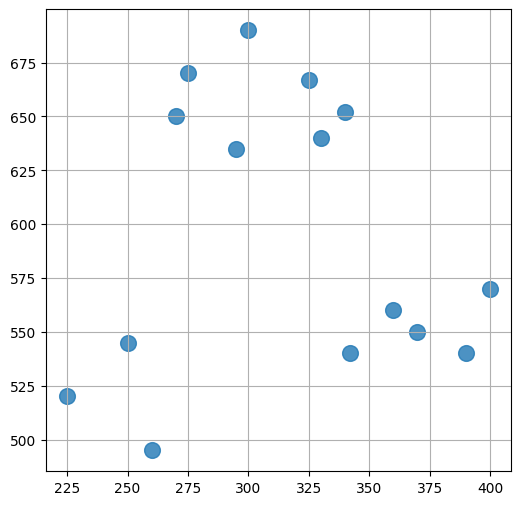

In [5]:
X = np.array([
    [300, 690],
    [270, 650],
    [325, 667],
    [330, 640],
    [275, 670],
    [295, 635],
    [340, 652],

    [400, 570],
    [390, 540],
    [370, 550],
    [342, 540],
    [360, 560],

    [250, 545],
    [225, 520],
    [260, 495],
])

plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], s=128, alpha=0.8)
plt.grid()
plt.show()

Мы видим, что здесь порядки координат большие, поэтому будем использовать eps=75 - это первый параметр DBSCAN (радиус, в котором ищутся соседние точки). Второй параметр, известный нам как min_points, здесь называется min_samples. Его пока поставит равным 2:

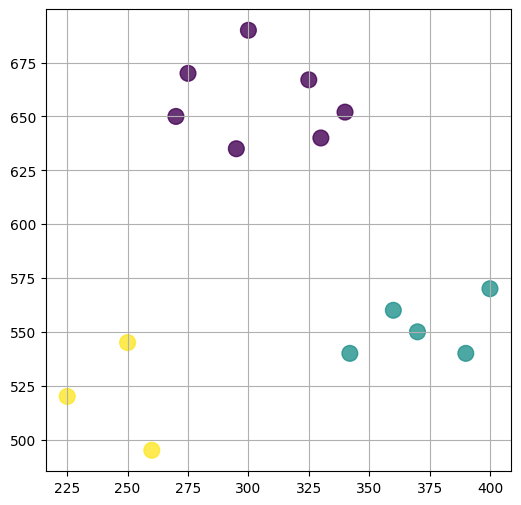

In [6]:
from sklearn.cluster import DBSCAN

model = DBSCAN(eps=75, min_samples=2) # создаём модель, задаём параметры
clusters = model.fit_predict(X) # обучаем модель на нашем датасете и смотрим на его же кластеризацию
plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], c=clusters, s=128, cmap='viridis', alpha=0.8)
plt.grid()
plt.show()

Теперь посмотрим на другие комбинации параметров. Чтобы рисовать шум (чёрным цветом, квадратиками), мы будем использовать фичи numpy, чтобы отедлять точки с класетром номер -1 (так DBSCAN помечает шум):

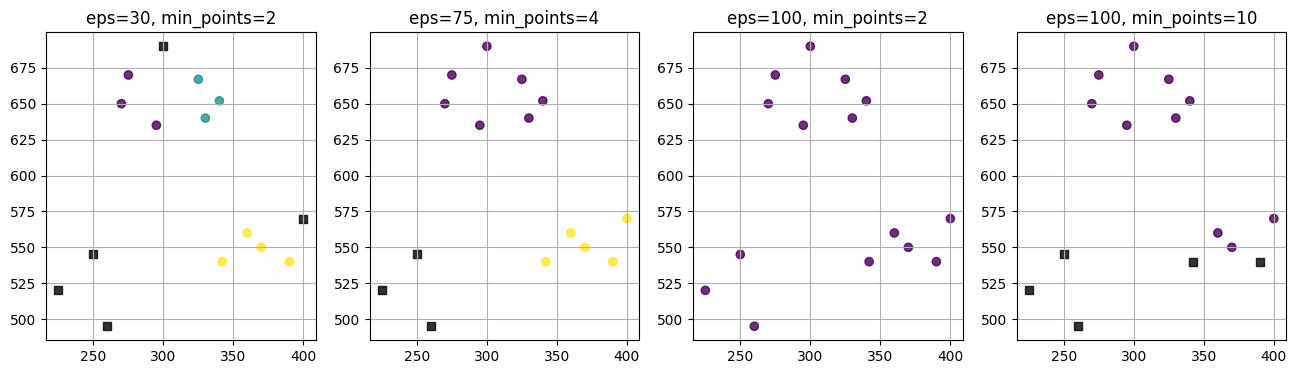

In [7]:
plt.figure(figsize=(16, 4))

for i, (eps, min_points) in enumerate([(30, 2), (75, 4), (100, 2), (100, 10)]):
  model = DBSCAN(eps=eps, min_samples=min_points)
  clusters = model.fit_predict(X)
  plt.subplot(1, 4, i + 1)
  plt.scatter(X[clusters != -1, 0], X[clusters != -1, 1], c=clusters[clusters != -1], cmap='viridis', alpha=0.8) # точки, попавшие в кластер
  plt.scatter(X[clusters == -1, 0], X[clusters == -1, 1], c='black', marker='s', alpha=0.8) # шум
  plt.title(f'eps={str(eps)}, min_points={str(min_points)}')
  plt.grid()

### Датасеты посложнее и метрики

Теперь мы можем применить DBSCAN к нашим примерам из прошлго раздела. Обратите внимание, что разный маштаб графиков (а точнее, самих данных) требует разный eps:

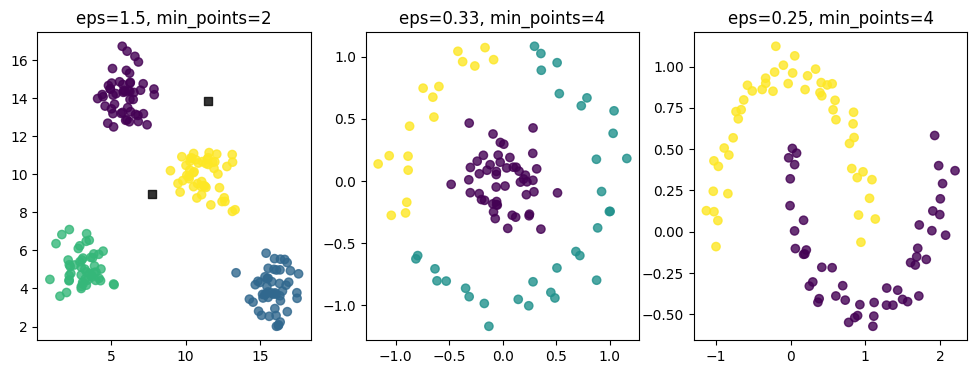

In [8]:
plt.figure(figsize=(12, 4))
for i, (eps, min_points) in enumerate([(1.5, 2), (0.33, 4), (0.25, 4)]):
    plt.subplot(1, 3, i + 1)
    model = DBSCAN(eps=eps, min_samples=min_points)
    X = datasets[i][0]
    clusters = model.fit_predict(X)
    plt.scatter(X[clusters != -1, 0], X[clusters != -1, 1], c=clusters[clusters != -1], cmap='viridis', alpha=0.8)
    plt.scatter(X[clusters == -1, 0], X[clusters == -1, 1], c='black', marker='s', alpha=0.8)
    plt.title(f'eps={str(eps)}, min_points={str(min_points)}')

Как мы видим, в первом графике самые дальние точки (справедливо) объявляются шумом. Третий график кластерищуется хорошо. А вот для второго сложно поймать значение eps, при котором кластеров не 3 и не 1. Давайте попробуем разные метрикии расстояния. В sklearn они задаются параметром metric (по-умолчанию там стоит Евклидово расстояние):

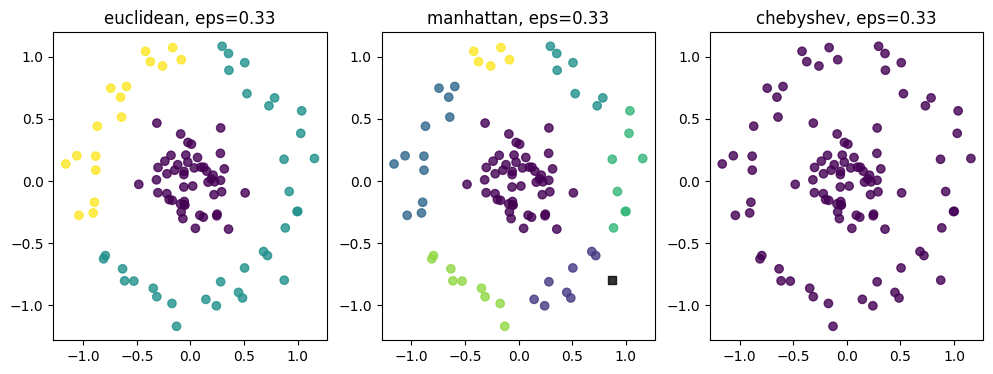

In [9]:
eps = 0.33
min_points = 2
X = datasets[1][0]

plt.figure(figsize=(12, 4))
for i, metric in enumerate(['euclidean', 'manhattan', 'chebyshev']):
    plt.subplot(1, 3, i + 1)
    model = DBSCAN(eps=eps, min_samples=min_points, metric=metric)
    clusters = model.fit_predict(X)
    plt.scatter(X[clusters != -1, 0], X[clusters != -1, 1], c=clusters[clusters != -1], cmap='viridis', alpha=0.8)
    plt.scatter(X[clusters == -1, 0], X[clusters == -1, 1], c='black', marker='s', alpha=0.8)
    plt.title(f'{metric}, eps={str(eps)}')

Увы, не все датасеты хорошо поддаются алгоритмам машинного обучения. Но картинка выше хорошо демонстрирует, как важны метрики расстояния.

Однако мы можем попробовать исправить ситуацию, сделав преобразование данных. Это часто применяется для улучшения работы алгоритмов. Здесь (это можно понять из уравнение окружности) должно помочь возведение координат к квадрат:

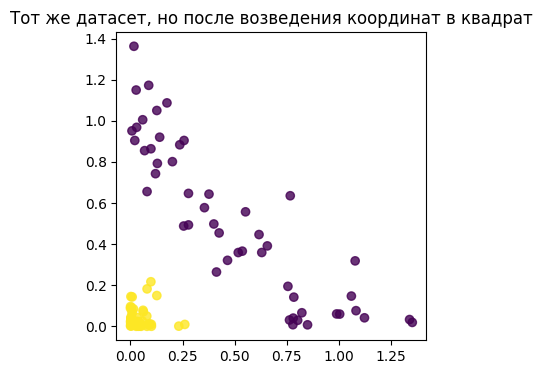

In [10]:
plt.figure(figsize=(4, 4))
X = datasets[1][0] ** 2 # в numpy можно возвести сразу все элементы массива, причём работает это быстрее цикла for
y = datasets[1][1]
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', alpha=0.8)
plt.title('Тот же датасет, но после возведения координат в квадрат')
plt.show()

А для таких случаев с углом наклона в 45 градусов, как мы уже знаем, отлично подходит Манхэттенское расстояние:

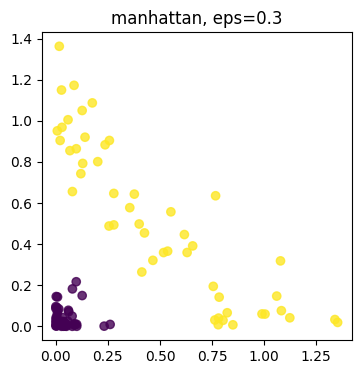

In [11]:
eps = 0.3
min_points = 2
model = DBSCAN(eps=eps, min_samples=min_points, metric='manhattan')
clusters = model.fit_predict(X)

plt.figure(figsize=(4, 4))
plt.scatter(X[clusters != -1, 0], X[clusters != -1, 1], c=clusters[clusters != -1], cmap='viridis', alpha=0.8)
plt.scatter(X[clusters == -1, 0], X[clusters == -1, 1], c='black', marker='s', alpha=0.8)
plt.title(f'manhattan, eps={str(eps)}')
plt.show()

Очевидно, что раз мы теперь в clusters знаем ответы для преобразованных данных, значит мы знаем их и для данных до преобразования (это просто тот же массив clusters).

### Масштабирование данных

Говоря о преобразованиях, нельзя не затронуть одну важную для машинного обучения вещь. Посмотрим на такой датасет:

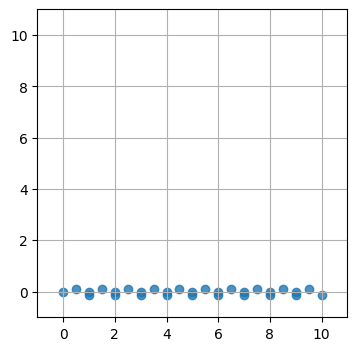

In [12]:
x = np.concatenate((np.arange(0, 10), np.arange(0.5, 10, 1), np.arange(1, 11))) # объединение нескольких массивов в один большой
y = np.repeat([0.0, 0.1, -0.15], 10) # каждое значение из списка будет повторено 10 раз

plt.figure(figsize=(4, 4))
plt.scatter(x, y, alpha=0.8)
plt.xlim(-1, 11)
plt.ylim(-1, 11)
plt.grid()
plt.show()

Кажется, что это один кластер. И алгоритм точно скажет нам так. Однако давайте сделаем другой масштаб по оси Y:

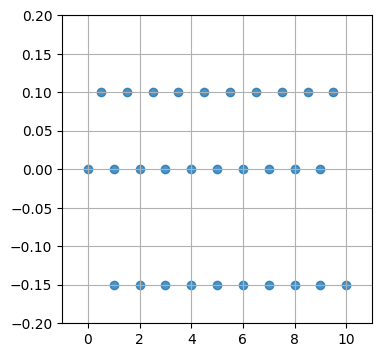

In [13]:
plt.figure(figsize=(4, 4))
plt.scatter(x, y, alpha=0.8)
plt.xlim(-1, 11)
plt.ylim(-0.2, 0.2)
plt.grid()
plt.show()

Теперь мы видим, что здесь на самом деле три кластера, просто они сильно похожи по координате Y. Тем не менее, если нам дали такие данных, эти чёткие отличия вряд ли являются случайностями. Тем более если, например, выясниться, что данные по оси Y - это вес каких-то объектах в тоннах, а по оси X - в килограммах. И вот уже отличие в 0.1 не кажется чем-то несущественным. Более того, нам могло не повезсти и в данных был бы пробел между, скажем, значениями 4 и 6 по координате X. Не было бы там точек. Тогда работая с ихсодным машстабом мы бы разбили всё на два кластера ($x < 4$ и $x > 6$), что было бы в корне неверно.

Как действовать, чтобы избегать таких проблем? Для этого существует **масштабирование данных**. Оно делается (как правило) независимо по каждой оси:

1) Рассмотрим значение координат объектов по некоторой оси. Найдём среди них $min$ и $max$ - наибольшее и наименьшее значения

2) Вычтем из всех значений $min$. Теперь (даже если $min < 0$) все значения будут неотрицательными, а наименьшее будет равняться $0$. Наибольшее будет равно $max - min$

3) Разделим все значения на $max - min$. Теперь все они принадлежат отрезку $[0; 1]$, при чём наименьшее значение точно $0$, а наибольшее точно $1$

Если проделать такое со всеми осями, масштаб по каждой будет отрезком $[0; 1]$, и даже если какие-то оси имени слишком маленькие/большие значения, больше этого не будет.

Поздравляю, мы изобрели MinMaxScaler. В sklearn он уже дружелюбно реализован за нас. Давайте применим его к нашему датасету:

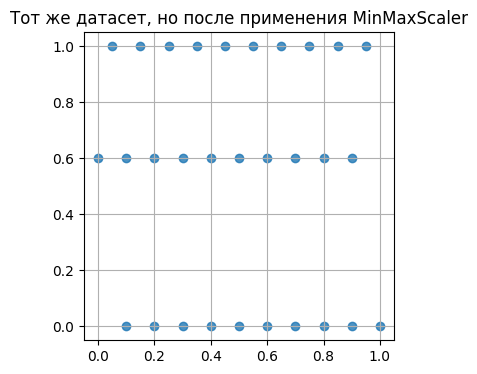

In [14]:
from sklearn.preprocessing import MinMaxScaler

X = np.column_stack((x, y)) # объединяем координаты объектов в одну матрицу
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

plt.figure(figsize=(4, 4))
plt.scatter(X[:, 0], X[:, 1], alpha=0.8)
plt.title('Тот же датасет, но после применения MinMaxScaler')
plt.grid()
plt.show()

Смысл масштабирования в том, что он не меняет масштаб координат относительно друг друга в рамках одной оси, но делает честнее соотношение координат по разным осям. Разумеется, бывают ситуации сложнее. Например, значения $min$ и $max$ могут быть выбросами или шумом, тогда MinMaxScaler не поможет. Для таких случаев существуют другие методы. Например, StandardScaler масштабирует данные так, чтоюы по всем осям были одинаковые матожидание и дисперсия. Это решает проблему выбросов, но теперь шкалы не фиксированные $[0; 1]$. А вообще, всегда надо анализировать, в каких единицах измерения и масштабах данны данные, какие у них диапазоны и разбросы значений. И уже после этого анализа можно грамотно выбрать методы масштабирования.

### Многомерные ирисы

Теперь применим все накопленные знания к реальным данным. Будем использовать популярный датасет из sklearn (да, там есть и реальные датасеты) с тремя видами ирисов (растений):

In [15]:
import pandas as pd # библиотека для удобной работы с датасетами
from sklearn.datasets import load_iris

# Загружаем датаест
iris_df, iris_target = load_iris(as_frame=True, return_X_y=True)
X = iris_df.values # признаки, их всего 4
y = iris_target.values # классы ирисов

Всего у нас 4 признака (то есть ирисы будут представлены точками в четырёхмерном пространстве):

*   Длина чашелистика
*   Ширина чашелистика
*   Длина лепестка
*   Ширина лепестка

Внимательный читатель уже мог заметить, что перед нами задача классификации: классы ирисов уже даны. Мы же попробуем свести её к задаче кластеризации, как описывалось в статье.

Так как адекватно рисовать 4D графики человечество пока не научилось, нарисуем проекции на разные плоскости:

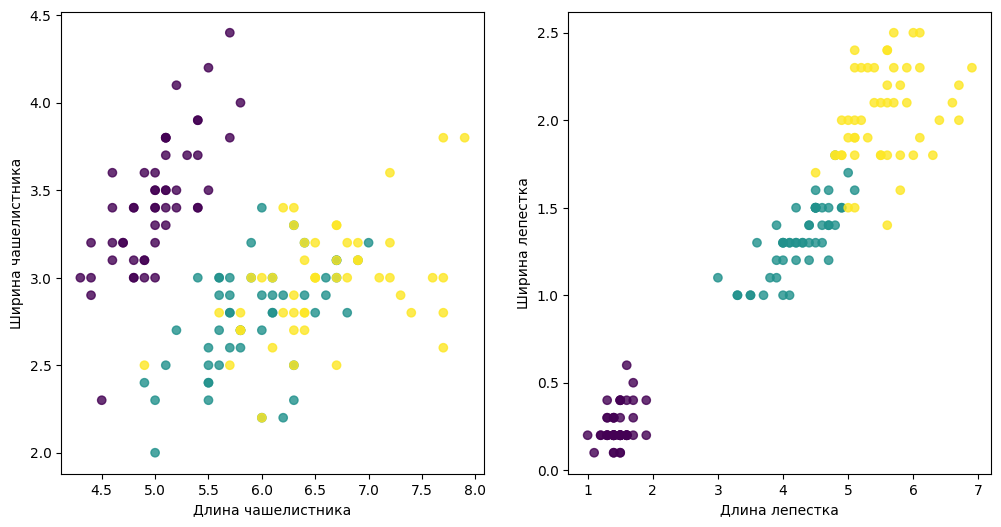

In [16]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', alpha=0.8)
plt.xlabel('Длина чашелистника')
plt.ylabel('Ширина чашелистника')

plt.subplot(1, 2, 2)
plt.scatter(X[:, 2], X[:, 3], c=y, cmap='viridis', alpha=0.8)
plt.xlabel('Длина лепестка')
plt.ylabel('Ширина лепестка')

plt.show()

Хоть все данные и даны в сантиметрах, масштабирование может быть полезно:

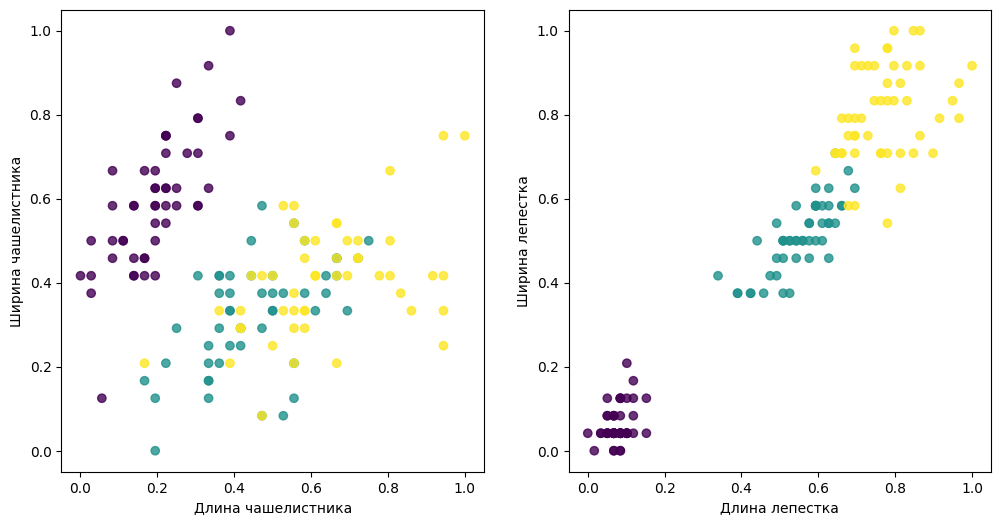

In [17]:
scaler = MinMaxScaler()
Xsc = scaler.fit_transform(X)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.scatter(Xsc[:, 0], Xsc[:, 1], c=y, cmap='viridis', alpha=0.8)
plt.xlabel('Длина чашелистника')
plt.ylabel('Ширина чашелистника')

plt.subplot(1, 2, 2)
plt.scatter(Xsc[:, 2], Xsc[:, 3], c=y, cmap='viridis', alpha=0.8)
plt.xlabel('Длина лепестка')
plt.ylabel('Ширина лепестка')

plt.show()

Подумайте, почему визуально ничего не изменилось. Напоминаем, что matplotlib по-умолчанию подбирает для нас удобные масштабы осей на графике (по сути, сам делает масштабированние), поэтому картинка может вводить в заблуждение. Важно всегда смотреть на оси!

Давайте применим кластеризацию к данным со второго графика:

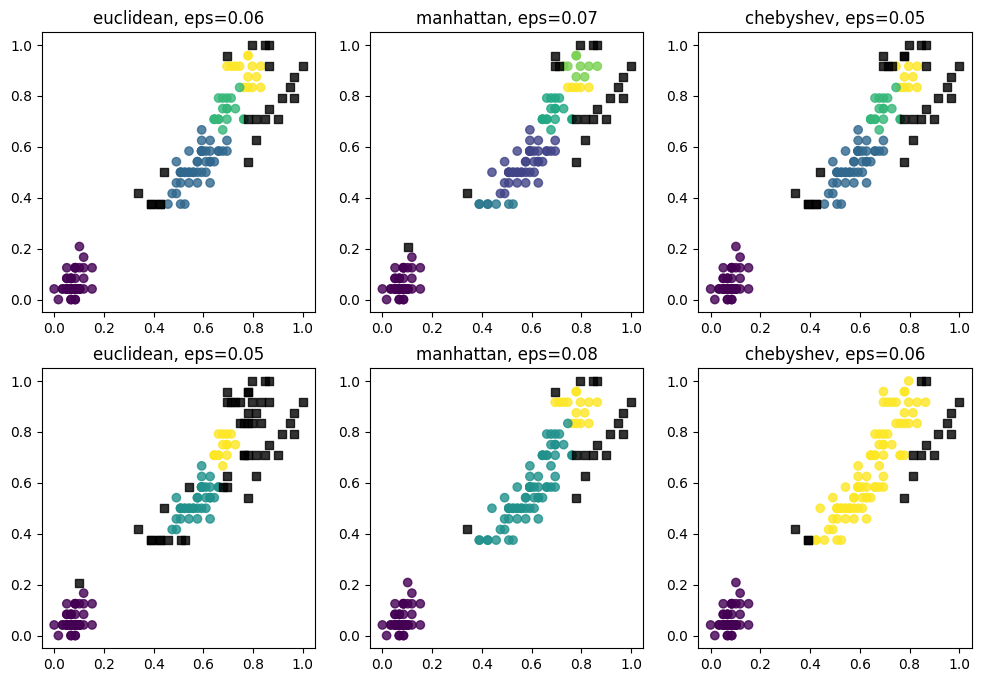

In [18]:
eps = [0.06, 0.07, 0.05, 0.05, 0.08, 0.06]
min_points = 7
X = Xsc[:, 2:]

plt.figure(figsize=(12, 8))
for i, metric in enumerate(['euclidean', 'manhattan', 'chebyshev'] * 2):
    plt.subplot(2, 3, i + 1)
    model = DBSCAN(eps=eps[i], min_samples=min_points, metric=metric)
    clusters = model.fit_predict(X)
    plt.scatter(X[clusters != -1, 0], X[clusters != -1, 1], c=clusters[clusters != -1], cmap='viridis', alpha=0.8)
    plt.scatter(X[clusters == -1, 0], X[clusters == -1, 1], c='black', marker='s', alpha=0.8)
    plt.title(f'{metric}, eps={str(eps[i])}')

Как мы видим, достаточно проблематично выделить подходящие кластеры. Не зная ответа вообще невозможно. Давайте попробуем применить кластеризацию с учётом сразу всех 4 осей, но отображать результат будем так же на плоскость:

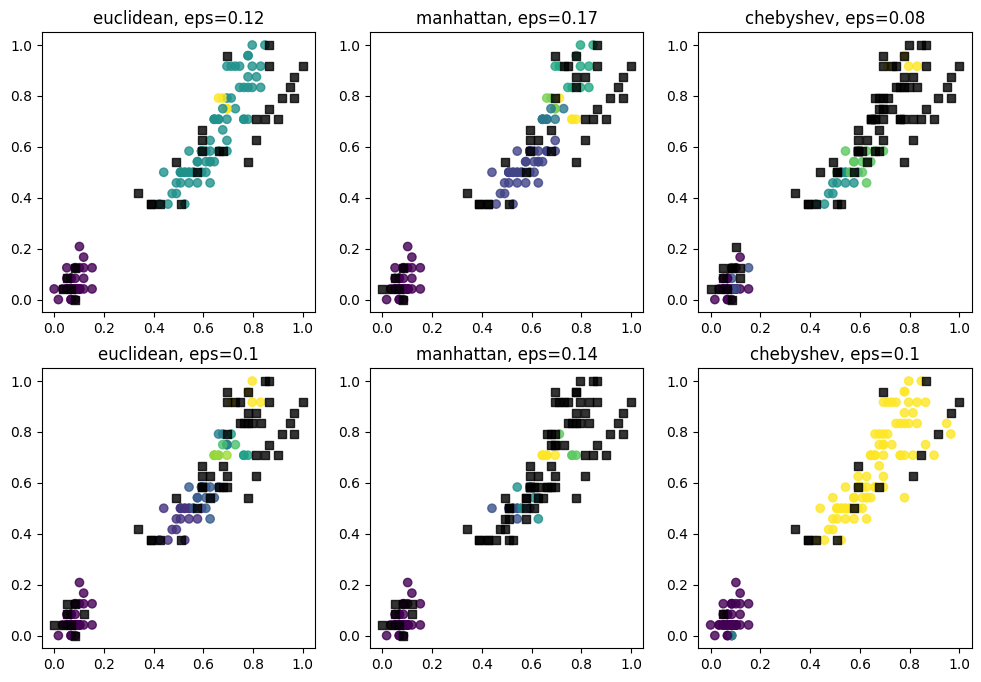

In [19]:
eps = [0.12, 0.17, 0.08, 0.1, 0.14, 0.1]
min_points = 4
X = Xsc[:, 2:]

plt.figure(figsize=(12, 8))
for i, metric in enumerate(['euclidean', 'manhattan', 'chebyshev'] * 2):
    plt.subplot(2, 3, i + 1)
    model = DBSCAN(eps=eps[i], min_samples=min_points, metric=metric)
    clusters = model.fit_predict(Xsc)
    plt.scatter(X[clusters != -1, 0], X[clusters != -1, 1], c=clusters[clusters != -1], cmap='viridis', alpha=0.8)
    plt.scatter(X[clusters == -1, 0], X[clusters == -1, 1], c='black', marker='s', alpha=0.8)
    plt.title(f'{metric}, eps={str(eps[i])}')

Кажется, стало хуже. В принципе, из графика для первых двух координат было видно, что там два класса тесно переплетены, так что такое ухудшение было ожидаемо.

Конечно, существует много методов, справляющихся с этим датасетом на порядок лучше. И тем не менее, с точки зрения разведочного анализа данных мы смогли понять многое: мы увидели, что один кластер легко отделяется, а два других кластера сильно переплетены, а также поняли, что это переплетение по большей части происходит по первым двум координатам.

## Свой DBSCAN

Давайте попробуем написать простую реализацию DBSCAN на Python. Для наглядности не будем пользоваться numpy. Пусть точки будут задаваться кортежами чисел - координатами, а параметрами алгоритма будут eps, min_points и dist(p1, p2) - функция, вычисляющая расстояние между двумя точками. Сначала напишем разные реализации такой функции на основе уже известных нам метрик расстояния:

In [20]:
def euclidean(p1, p2):
  s = 0
  for i in range(len(p1)): # перебираем все оси, готовы к любому числу измерений
    s += (p1[i] - p2[i]) ** 2 # сумма квадратов
  return s ** 0.5 # извлекаем корень

def manhattan(p1, p2):
  s = 0
  for i in range(len(p1)):
    s += abs(p1[i] - p2[i]) # важно не забыть про модуль
  return s

def chebyshev(p1, p2):
  max_dist = 0
  for i in range(len(p1)):
    max_dist = max(max_dist, abs(p1[i] - p2[i])) # важно не забыть про модуль
  return max_dist

In [21]:
# проверим, что всё работает
p1 = (1, 2, 3)
p2 = (4, 2, -1)

print('euclidean:', euclidean(p1, p2))
print('manhattan:', manhattan(p1, p2))
print('chebyshev:', chebyshev(p1, p2))

euclidean: 5.0
manhattan: 7
chebyshev: 4


Обратите внимание, что все эти функции могут работать с точками с любым количеством координат. Вы можете написать и свои функции, причём они могут работать не только с точками, но и с какими-то более сложными объектами, которые вы хотите кластеризовать.

Теперь напишем функцию, которая будет находить всех соседей (в радиусе ) точки из списка:

In [22]:
def find_neighbors(p, points, eps, dist):
  """
  p - точка, для которой мы ищем соседей
  points - точки, среди которых мы ищем соседей
  eps - радиус, в котором мы ищем соседей
  dist - функция, вычисляющая расстояние между двумя точками
  Возвращает соседей в виде списка их индексов в points. Если p была в points, её индекс тоже будет в списке.
  """
  neighbors = []
  for i in range(len(points)):
    if dist(p, points[i]) <= eps:
      neighbors.append(i)
  return neighbors

Обычно при сравнении дробных чисел (если dist(p, points[i]) и eps дробные) нужно учитывать небольшую погрешность, но если для каких-то данных это чувствительно, лучше закладывать погрешность уже при выборе eps.

Также нам понадобится **очередь** (рассказывалось в статье), чтобы перебирать элементы кластера. Вообще, так как нам не важен порядок, подойдёт любая структура данных (например, список), позволяющая добавлять и извлекать элементы. Однако очередь работает немного быстрее. В Python она уже реализована:

In [23]:
from queue import Queue

q = Queue()

q.put(1) # добавляем элемент в конец очереди
q.put(2)
q.put(3)
print('Пуста ли очередь:', q.empty())

print(q.get()) # забираем первый элемент из очереди
print(q.get())
print(q.get())
print('Пуста ли очередь:', q.empty())

Пуста ли очередь: False
1
2
3
Пуста ли очередь: True


Вообще, самым быстрым вариантом был бы deque из модуля collections, но нам подойдёт и очередь.

Приступим к написанию самой функции кластеризации:

In [31]:
from sklearn import neighbors
def MyDBSCAN(points, eps, min_points=2, dist=euclidean): # по-умолчанию расстояние Евклидово, а min_points=2 не играет роли
  clusters = [-1] * len(points) # изначально все точки считаются шумом
  cnt_clusters = 0 # количество кластеров
  for i in range(len(points)): # перебираем каждую точку и смотрим, может ли она стать началом нового кластера
    if clusters[i] != -1:
      continue # точка уже была обработана другим кластером
    neighbors = find_neighbors(points[i], points, eps, dist)
    if len(neighbors) < min_points:
      continue # у точки слишком мало соседей, чтобы начать кластер
    clusters[i] = cnt_clusters # добавляем точку в кластер
    q = Queue() # создаём очередь
    for j in neighbors: # добавляем всех необработанных соседей в кластер и очередь
      if i != j and clusters[j] == -1:
        clusters[j] = cnt_clusters
        q.put(j)
    while not q.empty(): # пока в очереди есть вершины, пробуем расширить кластер
      v = q.get()
      neighbors = find_neighbors(points[v], points, eps, dist)
      if len(neighbors) >= min_points: # проверяем, что у точки достаточно соседей, чтобы быть внутренней и расширять кластер
        for j in neighbors: # добавляем всех необработанных соседей в кластер и очередь
          if v != j and clusters[j] == -1:
            clusters[j] = cnt_clusters
            q.put(j)
    cnt_clusters += 1 # завершили формирование кластера, увеличиваем счётчик
  return cnt_clusters, clusters # возвращаем кортеж из количества кластеров и номерами кластеров вершин

Здесь мы пользуемся тем фактом, что cnt_clusters можно использовать одновременно и как счётчик уже сформированных кластеров, и как номер текущего кластера (нумерация с 0).

Теперь протестируем на простом примере:

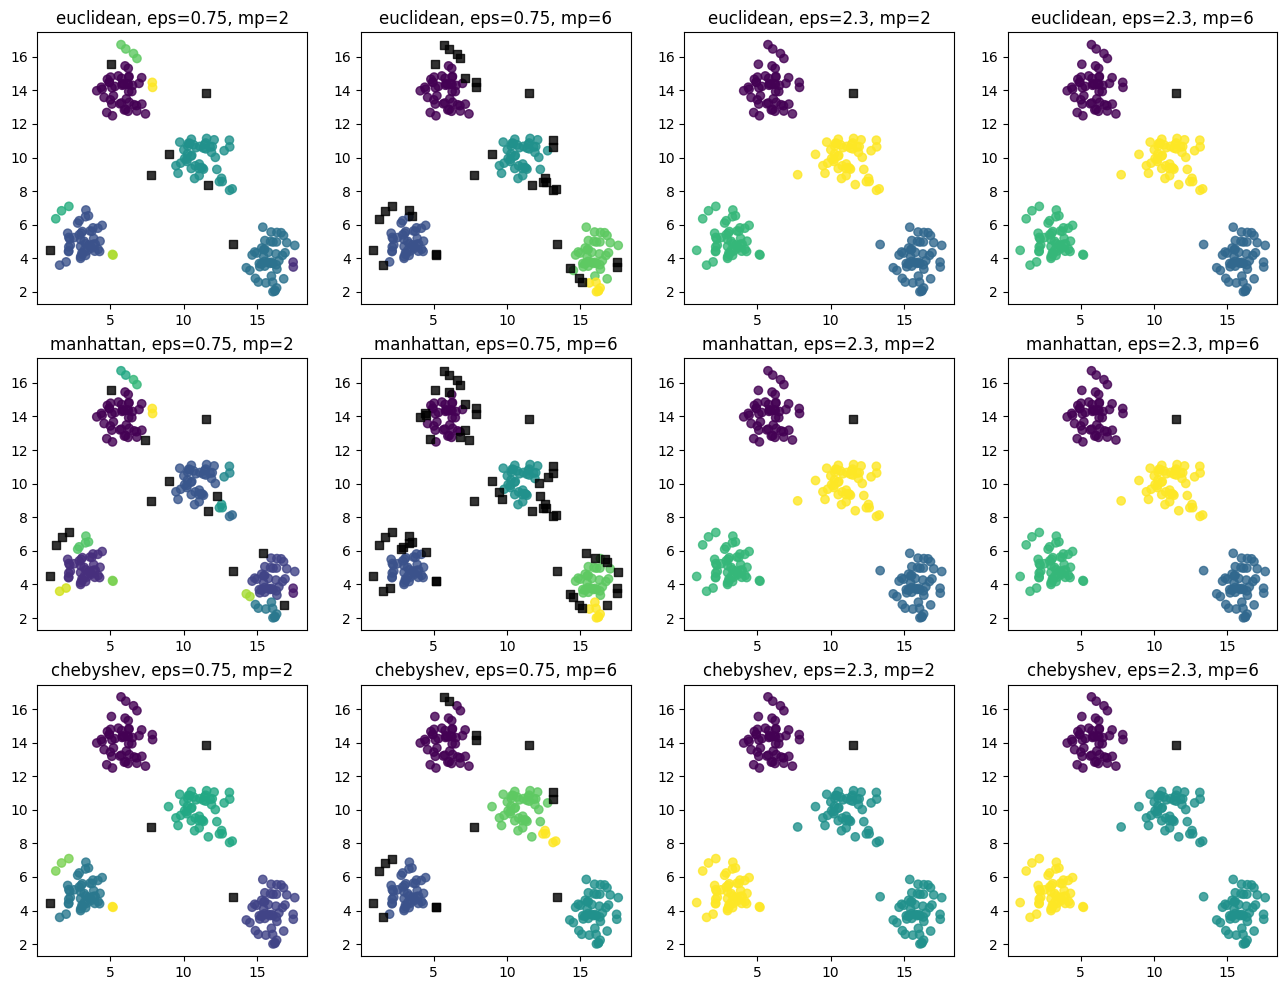

In [65]:
points = [tuple(float(e) for e in point) for point in datasets[0][0]] # преобразовываем один из датасетов в список кортежей

plt.figure(figsize=(16, 12))
num = 0
for dist in [euclidean, manhattan, chebyshev]:
  for eps in [0.75, 2.3]:
    for min_points in [2, 6]:
      cnt_clusters, clusters = MyDBSCAN(points, eps, min_points, dist)
      plt.subplot(3, 4, num + 1)
      num += 1
      clustering_x = [] # координаты x вершин из кластеров
      clustering_y = [] # координаты y вершин из кластеров
      clustering_c = [] # номера кластеров (для цветов) вершин из кластеров
      noise_x = [] # координаты x вершин из шума
      noise_y = [] # координаты y вершин из шума
      for i in range(len(points)):
        if clusters[i] == -1: # разделяем вершины на шум и остальные
          noise_x.append(points[i][0])
          noise_y.append(points[i][1])
        else:
          clustering_x.append(points[i][0])
          clustering_y.append(points[i][1])
          clustering_c.append(clusters[i])
      plt.scatter(clustering_x, clustering_y, c=clustering_c, cmap='viridis', alpha=0.8)
      plt.scatter(noise_x, noise_y, c='black', marker='s', alpha=0.8)
      metric = dist.__name__ # получаем имя функции расстояния
      plt.title(f'{metric}, eps={str(eps)}, mp={str(min_points)}')
plt.show()

### Бонус: кластеризация слов

Давайте рассмотрим пример расстояния не в системе координат. Пусть мы хотим кластеризовать слова, ища похожие по написанию (может пригодиться в автозамене, базах данных, поисковиках, системах антиплагиата и т.п.). Слово - это последовательность каких-то символов (у нас - букв, но вообще, это не обязательно). Специально для таких задач существует [редакторское расстояние](https://ru.wikipedia.org/wiki/%D0%A0%D0%B0%D1%81%D1%81%D1%82%D0%BE%D1%8F%D0%BD%D0%B8%D0%B5_%D0%9B%D0%B5%D0%B2%D0%B5%D0%BD%D1%88%D1%82%D0%B5%D0%B9%D0%BD%D0%B0).

Пусть у нас есть слово (последовательность символов). И разрешены операции трёх типов:

* Заменить одну букву (в одном месте, но любом) на другую
* Удалить одну букву (из одного, но любого места)
* Добавить одну букву (в любое, но одно место)

Минимальное количество операций, за которое из слова A можно получить слово B, и называется редакторским расстоянием между этими двумя словами.

Вычислить его можно с помощью [динамического программирования](https://education.yandex.ru/handbook/algorithms/article/zadacha-rasstoyanie-redaktirovaniya), но так как это не наша тема, просто приведу реализацию:

In [68]:
def word_dist(word1, word2):
  n = len(word1)
  m = len(word2)
  dp = [[0] * (m + 1) for _ in range(n + 1)]
  for i in range(n + 1):
    dp[i][0] = i
  for j in range(m + 1):
    dp[0][j] = j
  for i in range(1, n + 1):
    for j in range(1, m + 1):
      dp[i][j] = min(dp[i][j - 1] + 1, dp[i - 1][j] + 1, dp[i - 1][j - 1] + int(word1[i - 1] != word2[j - 1]))
  return dp[n][m]

In [69]:
for word1, word2 in [('кот', 'код'), ('мама', 'папа'), ('кот', 'корм'), ('арбалет', 'раритет')]:
  print(f'Расстояние между {word1} и {word2} =', word_dist(word1, word2))

Расстояние между кот и код = 1
Расстояние между мама и папа = 2
Расстояние между кот и корм = 2
Расстояние между арбалет и раритет = 4


Может возникнуть вопрос: а точно ли это корректное определение расстояния? Внимательный читатель помнит, что там было 3 требования. Читатель может самостоятельно доказать, что редакторское расстояние соотвествует всем трём, это не сложно :)

Теперь можно попробовать запустить кластеризацию набора слов с разными параметрами:

In [72]:
words = ['кот', 'мама', 'код', 'папа', 'корм', 'кит', 'корма', 'рама']

for eps in [1, 2, 3]:
  print('При eps =', eps)
  cnt_clusters, clusters = MyDBSCAN(words, eps, dist=word_dist)
  for i in range(cnt_clusters):
    print('Кластер номер', i + 1, end=': ')
    for j in range(len(clusters)):
      if clusters[j] == i:
        print(words[j], end=', ')
    print()
  print('Шум', end=': ')
  for j in range(len(clusters)):
      if clusters[j] == -1:
        print(words[j], end=', ')
  print('\n')

При eps = 1
Кластер номер 1: кот, код, кит, 
Кластер номер 2: мама, рама, 
Кластер номер 3: корм, корма, 
Шум: папа, 

При eps = 2
Кластер номер 1: кот, код, корм, кит, корма, 
Кластер номер 2: мама, папа, рама, 
Шум: 

При eps = 3
Кластер номер 1: кот, мама, код, папа, корм, кит, корма, рама, 
Шум: 

